
# Micrograph Sources

This tutorial will demonstrate how to set up and use ASPIRE's
``MicrographSource`` classes.


In [ ]:
%pip install aspire
%pip install starfile
%pip install mrcfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.5/426.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.2 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/phonchi/CryoParticleSegment.git

Cloning into 'CryoParticleSegment'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (270/270), done.
remote: Compressing objects: 100% (253/253), done.
remote: Total 270 (delta 141), reused 42 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (270/270), 32.01 MiB | 16.83 MiB/s, done.
Resolving deltas: 100% (141/141), done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tempfile
import time
import numpy as np

from aspire.source import ArrayMicrographSource

2025-09-17 00:38:07,920 INFO [numexpr.utils] NumExpr defaulting to 8 threads.


DEBUG:2025-09-17 00:38:09,834:jax._src.path:41: etils.epath found. Using etils.epath for file I/O.


In [ ]:
import sys

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/simulation')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)


Here, we need to provide the 3D volume, 3D mask and the metadata containing CTF in a STAR file to generate the simulated data.


In [ ]:
# @title  { display-mode: "form" }

VOLUME_PATH = "/content/J3_004_volume_map.mrc" # @param {type:"string"}
MASK_PATH = "/content/J3_004_volume_mask_refine.mrc" # @param {type:"string"}
STAR_PATH = "/content/particles.star" # @param {type:"string"}
DATASET_DIR = "/content/drive/MyDrive/research_xc/dataset" # @param {type:"string"}

## Creating a Micrograph Simulation
A ``MicrographSimulation`` is populated with particle projections
from a ``Volume``, so we'll begin by generating a ``Volume``.



In [11]:
from aspire.source import MicrographSimulation
from aspire.volume import Volume
import numpy as np
import pandas as pd
import starfile
# from aspire.volume import AsymmetricVolume

# # Generate one (100,100,100) ``Volume``.
# vol = AsymmetricVolume(
#     L=100,
#     C=1,
#     seed=1234,
#     dtype=np.float32,
# ).generate()

# file_path = os.path.join(
#     os.path.dirname(os.getcwd()), "aspire/data", "5lzf-pdb-bundle1.mrc"
# )
vol = Volume.load(VOLUME_PATH, dtype=np.float64)

FileNotFoundError: [Errno 2] No such file or directory: '/content/J3_004_volume_map.mrc'

In [ ]:
refine_result_path = STAR_PATH
refine_result = starfile.read(refine_result_path)
refine_result = refine_result['particles']
refine_result

,rlnImageName,rlnAngleRot,rlnAngleTilt,rlnAnglePsi,rlnOriginXAngst,rlnOriginYAngst,rlnDefocusU,rlnDefocusV,rlnDefocusAngle,rlnPhaseShift,rlnCtfBfactor,rlnOpticsGroup,rlnRandomSubset,rlnClassNumber
0,000001@J1/imported/009450134240439197669_Falco...,27.232986,101.924133,118.272339,2.804344,-0.071906,16114.192383,15825.589844,2.787752,0.0,0.0,2,1,1
1,000002@J1/imported/009450134240439197669_Falco...,135.509964,80.956985,63.972885,-0.359531,6.112031,16201.632812,15913.030273,2.787752,0.0,0.0,2,2,1
2,000003@J1/imported/009450134240439197669_Falco...,142.685806,71.912315,127.747437,6.974906,1.653844,15950.035156,15661.432617,2.787752,0.0,0.0,2,1,1
3,000004@J1/imported/009450134240439197669_Falco...,132.415039,100.085007,61.299046,-1.078594,0.647156,16118.767578,15830.165039,2.787752,0.0,0.0,2,2,1
4,000005@J1/imported/009450134240439197669_Falco...,-154.759628,108.400917,-88.782585,2.229094,4.386281,15892.583984,15603.981445,2.787752,0.0,0.0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49386,000668@J1/imported/002543179792178278827_Falco...,-32.930584,162.047668,-111.021210,-34.165249,-25.660749,23859.585938,23600.019531,-67.061165,0.0,0.0,2,1,1
49387,000670@J1/imported/002543179792178278827_Falco...,160.914749,158.862503,-41.369183,-8.125406,-4.817719,23550.390625,23290.824219,-67.061165,0.0,0.0,2,2,1
49388,000673@J1/imported/002543179792178278827_Falco...,85.890823,150.898941,-7.460076,-18.479906,-7.981594,24017.113281,23757.546875,-67.061165,0.0,0.0,2,1,1
49389,000678@J1/imported/002543179792178278827_Falco...,131.126938,165.740753,7.338231,-31.998281,-38.901279,24291.025391,24031.458984,-67.061165,0.0,0.0,2,2,1


In [ ]:
# @title  { vertical-output: true, display-mode: "form" }
n_micrographs = 84 # @param {type:"integer"}
micrograph_size = 4096 # @param {type:"integer"}
snr = 0.005 # @param {type:"number"}

In [ ]:
random_defocus_values = refine_result.rlnDefocusV.sample(n_micrographs, random_state=42)

In [ ]:
random_defocus_values

,rlnDefocusV
39497,27063.888672
26366,19748.894531
36154,24486.117188
11165,28391.523438
48059,30975.164062
...,...
1738,27914.580078
11444,-65196.367188
508,16059.564453
28624,23914.521484


In [ ]:
n_particles_per_micrograph = 150
seed = 42

### CTF Filters
By default, no CTF corruption is configured. To apply CTF filters,
we have to pass them as arguments to the ``MicrographSimulation``.
It is possible to apply a single CTF, different CTF per-micrograph
or different CTF per-particle by configuring a list of matching size.



In [ ]:
from aspire.operators import RadialCTFFilter

# Create our CTF Filter and add it to a list.
# This configuration will apply the same CTF to all particles.
# ctfs = [
#     RadialCTFFilter(pixel_size=1.16, voltage=300, defocus=16500, Cs=2.7, alpha=0.03, B=0),
# ]


#defocus_min = 0.7e4              # Minimum defocus value (in angstroms).
#defocus_max = 2.6e4              # Maximum defocus value (in angstroms).
#defocus_ct = n_micrographs
#random_defocus_values = np.random.uniform(defocus_min, defocus_max, defocus_ct)
# Create filters
ctfs = [RadialCTFFilter(pixel_size=1.77, voltage=300, defocus=d, Cs=2.7, alpha=0.1)
        for d in random_defocus_values]

src = MicrographSimulation(
    vol,
    particles_per_micrograph=n_particles_per_micrograph,
    micrograph_size=4096,
    micrograph_count=n_micrographs,
    particle_amplitudes=1,
    ctf_filters=ctfs,
    seed=seed,
)

# Plot the micrographs
#src.images[:].show()

2025-06-18 02:22:04,209 INFO [aspire.source.image] Creating Simulation with 12600 images.


In [ ]:
src.save(f'{DATASET_DIR}/sim_images/', name_prefix='sim_image')

2025-06-18 03:11:54,946 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,969 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,972 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,975 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,978 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,981 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,984 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,987 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,990 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,993 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,996 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 03:11:54,999 INFO [aspire.storage.starfile]

[('/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_0.mrc',
  '/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_0.star'),
 ('/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_1.mrc',
  '/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_1.star'),
 ('/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_2.mrc',
  '/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_2.star'),
 ('/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_3.mrc',
  '/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_3.star'),
 ('/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_4.mrc',
  '/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_4.star'),
 ('/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_5.mrc',
  '/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_5.star'),
 ('/content/drive/MyDrive/research_xc/dataset/sim_images/sim_image_6.mrc',
  '/content/d

In [ ]:
vol = Volume.load(MASK_PATH, dtype=np.float64)

2025-06-18 03:30:44,351 INFO [aspire.volume.volume] /content/J3_004_volume_mask_refine.mrc with dtype float32 loaded as <class 'numpy.float64'>


In [ ]:
from aspire.operators import RadialCTFFilter

# Create our CTF Filter and add it to a list.
# This configuration will apply the same CTF to all particles.
# ctfs = [
#     RadialCTFFilter(pixel_size=1.16, voltage=300, defocus=16500, Cs=2.7, alpha=0.03, B=0),
# ]


#defocus_min = 0.7e4              # Minimum defocus value (in angstroms).
#defocus_max = 2.6e4              # Maximum defocus value (in angstroms).
#defocus_ct = n_micrographs
#random_defocus_values = np.random.uniform(defocus_min, defocus_max, defocus_ct)
# Create filters
# ctfs = [RadialCTFFilter(pixel_size=1.77, voltage=300, defocus=d, Cs=2.7, alpha=0.1)
#         for d in random_defocus_values]

src = MicrographSimulation(
    vol,
    particles_per_micrograph=n_particles_per_micrograph,
    micrograph_size=4096,
    micrograph_count=n_micrographs,
    particle_amplitudes=1,
#     ctf_filters=ctfs,
    seed=seed,
)

# Plot the micrographs
#src.images[:].show()

2025-06-18 03:30:48,789 INFO [aspire.source.image] Creating Simulation with 12600 images.


In [ ]:
src.save(f'{DATASET_DIR}/sim_images2/', name_prefix='sim_image')

2025-06-18 04:11:57,541 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,545 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,548 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,550 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,552 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,554 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,555 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,558 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,560 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,562 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,564 INFO [aspire.storage.starfile] Created StarFile with blocks: 
2025-06-18 04:11:57,566 INFO [aspire.storage.starfile]

[('sim_images2/sim_image_0.mrc', 'sim_images2/sim_image_0.star'),
 ('sim_images2/sim_image_1.mrc', 'sim_images2/sim_image_1.star'),
 ('sim_images2/sim_image_2.mrc', 'sim_images2/sim_image_2.star'),
 ('sim_images2/sim_image_3.mrc', 'sim_images2/sim_image_3.star'),
 ('sim_images2/sim_image_4.mrc', 'sim_images2/sim_image_4.star'),
 ('sim_images2/sim_image_5.mrc', 'sim_images2/sim_image_5.star'),
 ('sim_images2/sim_image_6.mrc', 'sim_images2/sim_image_6.star'),
 ('sim_images2/sim_image_7.mrc', 'sim_images2/sim_image_7.star'),
 ('sim_images2/sim_image_8.mrc', 'sim_images2/sim_image_8.star'),
 ('sim_images2/sim_image_9.mrc', 'sim_images2/sim_image_9.star'),
 ('sim_images2/sim_image_10.mrc', 'sim_images2/sim_image_10.star'),
 ('sim_images2/sim_image_11.mrc', 'sim_images2/sim_image_11.star'),
 ('sim_images2/sim_image_12.mrc', 'sim_images2/sim_image_12.star'),
 ('sim_images2/sim_image_13.mrc', 'sim_images2/sim_image_13.star'),
 ('sim_images2/sim_image_14.mrc', 'sim_images2/sim_image_14.star'),


In [ ]:
import mrcfile
import matplotlib.pyplot as plt
with mrcfile.open(f'{DATASET_DIR}/sim_images2/sim_image_83.mrc') as mrc:
    image = mrc.data.astype(np.float32)

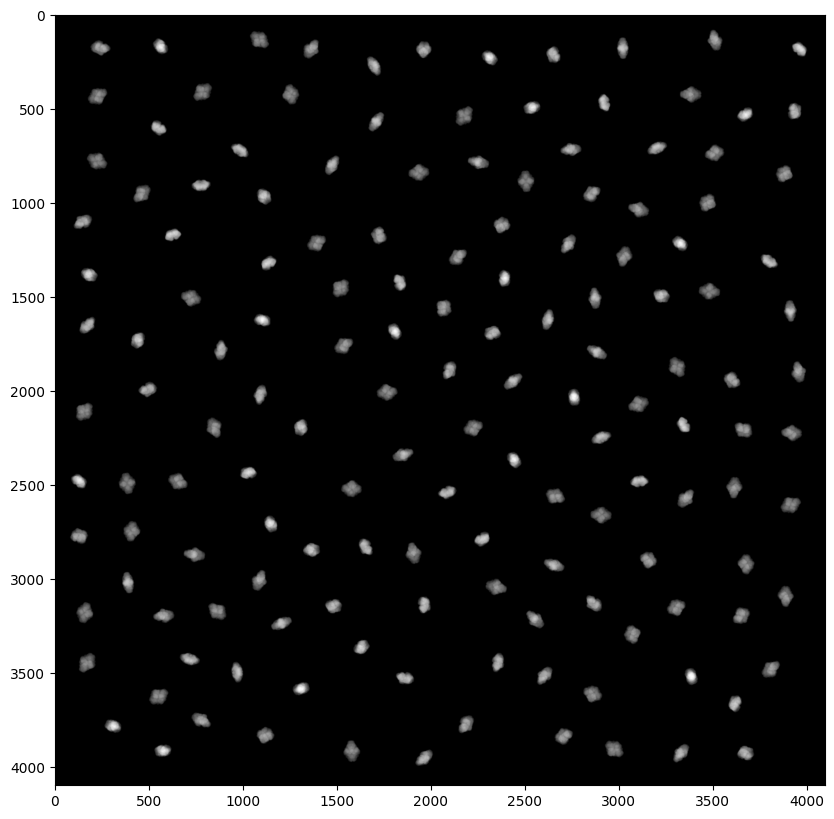

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image.squeeze(), cmap="gray");

## Add noise and generate synthetic mircorgaphs
By default, no noise corruption is configured.
To apply noise, pass a ``NoiseAdder`` to ``MicrographSimulation``.



In [ ]:
import mrcfile
with mrcfile.open(f'{DATASET_DIR}/sim_images/sim_image_83.mrc') as mrc:
    image = mrc.data.astype(np.float32)

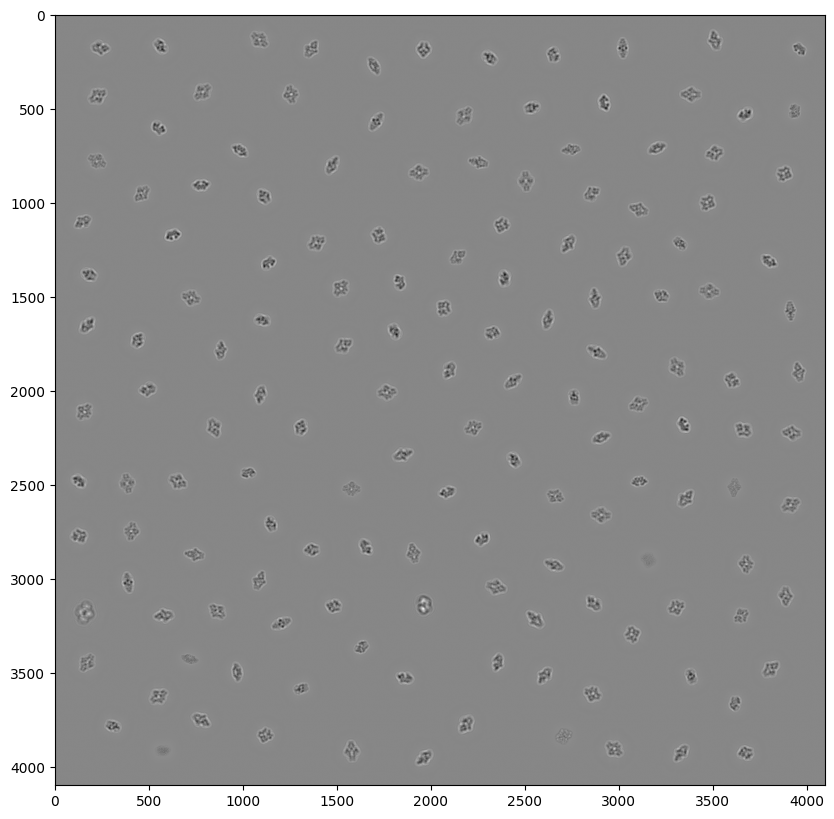

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image.squeeze(), cmap="gray");

In [ ]:
from tqdm.auto import tqdm
from pathlib import Path


from util import add_noise, numpy_to_PIL, threshold, processing, self2binary2

In [ ]:
noise_image_dir = Path(f"{DATASET_DIR}/noisy_sim")
os.makedirs(noise_image_dir, exist_ok=True)
for path in tqdm(list(Path(f'{DATASET_DIR}/sim_images').glob("**/*.mrc"))):
        with mrcfile.open(path) as mrc:
            image = mrc.data.astype(np.float32)
        noise_image = add_noise(image, snr)
        plt.figure(figsize=(10, 10))
        plt.imshow(noise_image.squeeze(), cmap='gray')
        plt.show()
        noise_image_path = noise_image_dir.joinpath(f"{path.stem}.npy")
        np.save(noise_image_path, noise_image.squeeze())

## Mask generation

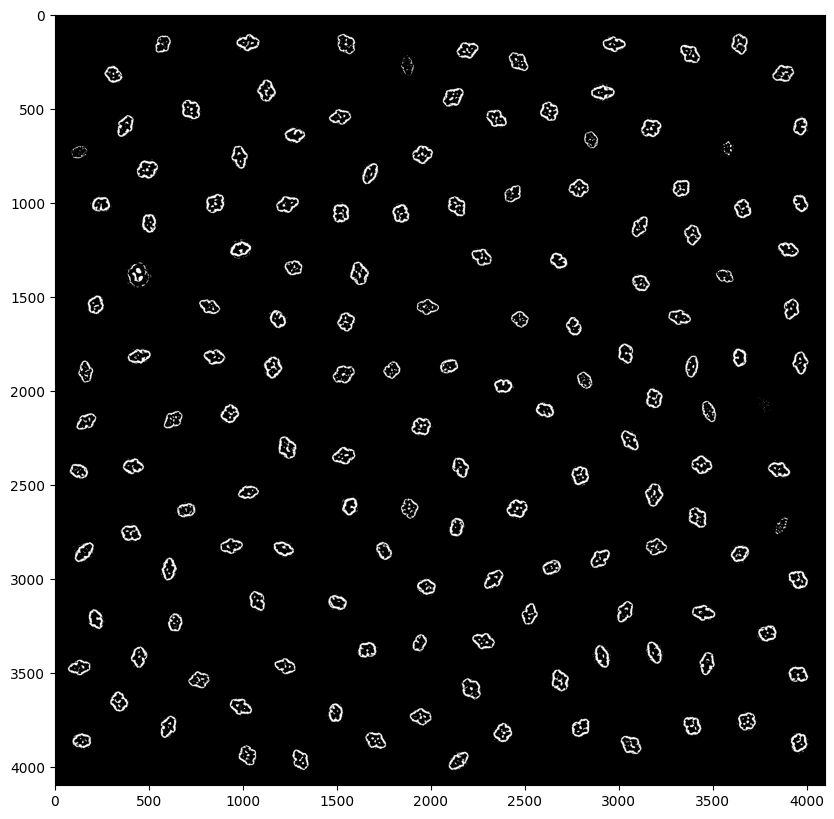

In [ ]:
with mrcfile.open(f"{DATASET_DIR}/sim_images/sim_image_0.mrc") as mrc:
    image = mrc.data.astype(np.float32)
clean_image = threshold(image[0])
plt.figure(figsize=(10, 10))
plt.imshow(clean_image.squeeze(), cmap="gray");

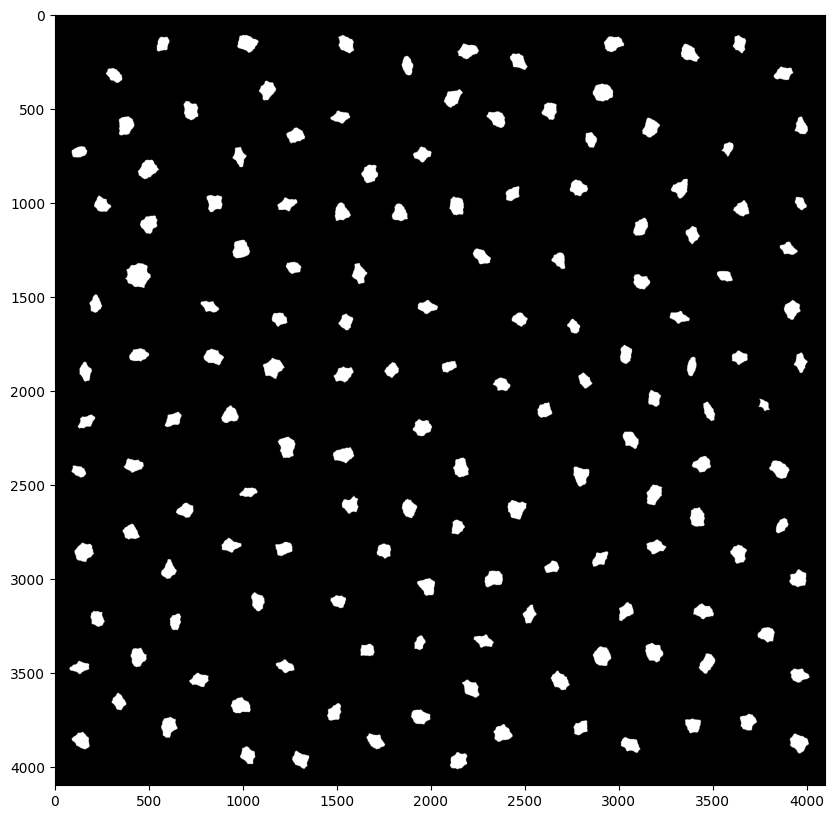

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(processing(clean_image.squeeze()), cmap="gray");

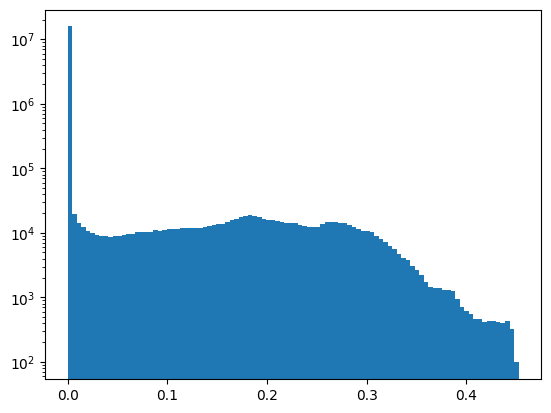

In [ ]:
with mrcfile.open(f"{DATASET_DIR}/sim_images2/sim_image_0.mrc") as mrc:
    image = mrc.data.astype(np.float32)

plt.hist(image.flatten(), bins=100, log=True)
plt.show();

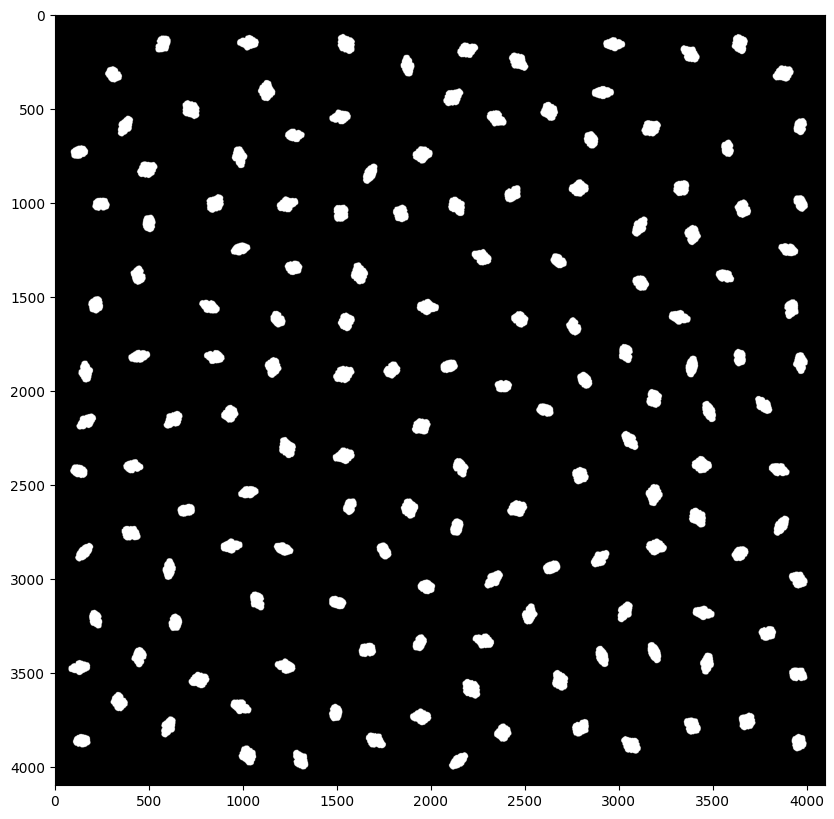

In [ ]:
clean_image = threshold(image[0])
plt.figure(figsize=(10, 10))
plt.imshow(clean_image, cmap="gray");

In [ ]:
import gc

clean_image_dir = Path(f"{DATASET_DIR}/ground_sim")
os.makedirs(clean_image_dir, exist_ok=True)
for path in tqdm(list(Path(f"{DATASET_DIR}/sim_images2").glob("**/*.mrc"))):
        with mrcfile.open(path) as mrc:
            image = mrc.data.astype(np.float32)
        clean_image = self2binary2(image[0])
        clean_image_path = clean_image_dir.joinpath(f"{path.stem}.png")
        numpy_to_PIL(clean_image).save(clean_image_path)
        plt.imshow(numpy_to_PIL(clean_image), cmap="gray")
        plt.show()
        gc.collect()